# Training a uNet model with BiaPy

In the [data_collection_IDR_stardist.ipynb] a training data set was created, consisting of phalloidin images in
`images/` and the corresponing nuclei labels in `labels/`. For training we need training, validation and test data.

## Why train a model at all?

On day 2 we used **generic** pretrained models: StarDist and Cellpose were trained on
thousands of images from many labs, so they work out of the box, as long as your images
and objects look like what they were trained on.

Here that is not the case. We want nuclei from the **actin** channel. No generic model
was trained for that: a nuclei model expects a DAPI-like signal, a cell model finds the
cells. So we train a **specific** model: small, trained on our own images, and it learns
exactly what our labels show — no more, and no better.

| | Generic pretrained model | Specific model |
| --- | --- | --- |
| Trained on | large, varied data from others | your own labelled images |
| Finds | what it was built for (nuclei, cells) | whatever your labels show |
| Your work | pick the model, set size and normalization | make labels, train, evaluate |
| Breaks when | your data differs from its training data | labels are poor, or new data differs from your training set |

Between the two sits **fine-tuning**: start from a trained model and continue training it
on your own images. That needs far fewer labels than starting from nothing.

In this notebook we do instance segmentation with a U-Net trained from scratch. In
`evaluation.ipynb` we compare the result with the generic StarDist and Cellpose models.

## Splitting the data

Three sets, with three different jobs:

- **training** — the images the network learns from
- **validation** — used *during* training to see whether the network is still
  improving or has started to memorise the training images (overfitting)
- **test** — held back completely. It is not used for training and not used to choose
  settings. It exists to answer the question how well does this model
  work on images it has never seen?

If you tune anything against the test set, it stops being a test set.

We write the training and test images into separate folders. The validation set is not
a folder: BiaPy takes a fraction of the training images for it, which keeps the split
in one place.

In [1]:
from pathlib import Path
import shutil
import random

DATA = Path('training_data')     # single folder from the preparation notebook
DATASET = Path('dataset')        # split copy used for training

TEST_FRACTION = 0.2              # held back until the very end
VALIDATION_FRACTION = 0.2        # taken from the training images by BiaPy

image_ids = sorted(p.stem for p in (DATA / 'images').glob('*.tif'))

random.seed(42)                  # we define a seed so that the split is the same every run, so results are comparable
random.shuffle(image_ids)

n_test = round(len(image_ids) * TEST_FRACTION)
test_ids = image_ids[:n_test]
train_ids = image_ids[n_test:]

print(f'{len(image_ids)} images: {len(train_ids)} train (of which '
      f'{round(len(train_ids) * VALIDATION_FRACTION)} for validation), {len(test_ids)} test')

100 images: 80 train (of which 16 for validation), 20 test


We copy the data to another folder where we split the train and test sets

In [2]:
# Copy each image and its labels into the folder for its split
for split, ids in [('train', train_ids), ('test', test_ids)]:
    for kind in ('images', 'labels'):
        folder = DATASET / split / kind
        folder.mkdir(parents=True, exist_ok=True)
        for image_id in ids:
            shutil.copy(DATA / kind / f'{image_id}.tif', folder / f'{image_id}.tif')

train_data_path = str(DATASET / 'train' / 'images')
train_data_gt_path = str(DATASET / 'train' / 'labels')
test_data_path = str(DATASET / 'test' / 'images')
test_data_gt_path = str(DATASET / 'test' / 'labels')

print('train:', train_data_path)
print('test: ', test_data_path)

train: dataset/train/images
test:  dataset/test/images


## Display the training data

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread

n_show = 3
examples = random.sample(train_ids, n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(8, 4 * n_show))
for row, image_id in zip(axes, examples):
    image = imread(DATASET / 'train' / 'images' / f'{image_id}.tif')
    labels = imread(DATASET / 'train' / 'labels' / f'{image_id}.tif')

    row[0].imshow(image, cmap='gray', vmin=np.percentile(image, 1), vmax=np.percentile(image, 99.8))
    row[0].set_title(f'{image_id}: image')
    row[1].imshow(np.ma.masked_equal(labels, 0), cmap='tab20', interpolation='nearest')
    row[1].set_title(f'labels ({len(np.unique(labels)) - 1} nuclei)')
    for ax in row:
        ax.axis('off')
plt.tight_layout()
plt.show()

A random split is fine here because every image comes from a different well, so the
images are independent of each other.

**That is not always the case:**

If your images were frames of a time lapse, or several slices from a z-stack, 
a random split would put nearly identical images in both the
training, valiation and the test set. The model would then score well on the test set simply
because it had already seen those images, which tells you nothing. In that case you
split by time lapse, or by well, not by image.

## Training settings

In [5]:
patch_size = 256          # the network is trained on crops of this size
input_channels = 1        # one channel in, the phalloidin image
epochs = 200              # one epoch is one pass over the training images
batch_size = 8           # number of crops processed in parallel on the GPU

output_path = 'training_output'
job_name = 'nuclei_from_phalloidin'
run_id = 1                # increase this to keep the results of an earlier run

base_config = '2d_instance_segmentation.yaml'          # template, not modified
run_config = '2d_instance_segmentation_config.yaml'    # written below, read by BiaPy

In [6]:
import yaml

with open(base_config) as f:
    biapy_config = yaml.safe_load(f)

# Where the data is
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path
biapy_config['DATA']['TEST']['PATH'] = test_data_path
biapy_config['DATA']['TEST']['GT_PATH'] = test_data_gt_path
biapy_config['DATA']['TEST']['LOAD_GT'] = True

# Validation is taken from the training images
biapy_config['DATA']['VAL']['FROM_TRAIN'] = True
biapy_config['DATA']['VAL']['SPLIT_TRAIN'] = VALIDATION_FRACTION

biapy_config['DATA']['PATCH_SIZE'] = f'({patch_size}, {patch_size}, {input_channels})'
biapy_config['TRAIN']['EPOCHS'] = epochs
biapy_config['TRAIN']['BATCH_SIZE'] = batch_size

# With very few epochs the charts are only drawn at the end, so ask for them sooner
if epochs < 10:
    biapy_config.setdefault('LOG', {})['CHART_CREATION_FREQ'] = 1

# Write the settings to the file BiaPy will read
with open(run_config, 'w') as f:
    yaml.safe_dump(biapy_config, f, sort_keys=False)

print(open(run_config).read())

SYSTEM:
  NUM_CPUS: -1
PROBLEM:
  TYPE: INSTANCE_SEG
  NDIM: 2D
  INSTANCE_SEG:
    DATA_CHANNELS: BC
DATA:
  PATCH_SIZE: (256, 256, 1)
  TRAIN:
    PATH: dataset/train/images
    GT_PATH: dataset/train/labels
    IN_MEMORY: true
  VAL:
    SPLIT_TRAIN: 0.2
    FROM_TRAIN: true
  TEST:
    PATH: dataset/test/images
    GT_PATH: dataset/test/labels
    IN_MEMORY: true
    LOAD_GT: true
    PADDING: (32,32)
AUGMENTOR:
  ENABLE: true
  RANDOM_ROT: true
  VFLIP: true
  HFLIP: true
MODEL:
  ARCHITECTURE: unet
  LOAD_CHECKPOINT: false
TRAIN:
  ENABLE: true
  OPTIMIZER: ADAMW
  LR: 0.0001
  BATCH_SIZE: 8
  EPOCHS: 200
  PATIENCE: 20
LOSS:
  CLASS_REBALANCE: true
TEST:
  ENABLE: true
  AUGMENTATION: false
  FULL_IMG: false



## Run the training

Start with a small number of epochs (10 or so) to check that everything runs, look at
the loss and IoU curves below, and only then train for longer. The output shows the progress of the training.

At the same time the results are saved in a folder.
The results 

In [7]:
import biapy.engine.base_workflow as bw
from tqdm import tqdm as _tqdm
def _quiet_tqdm(it, *a, **kw):
    try:
        if len(it) <= 1:
            kw["disable"] = True
    except TypeError:
        pass
    return _tqdm(it, *a, **kw)
bw.tqdm = _quiet_tqdm

In [8]:
from biapy import BiaPy

biapy = BiaPy(config=run_config, result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

Date     : 2026-09-16 18:23:35
Arguments: Namespace(config='2d_instance_segmentation_config.yaml', result_dir='training_output', name='nuclei_from_phalloidin', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : nuclei_from_phalloidin_1
BiaPy    : 3.6.8
Python   : 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
PyTorch  : 2.5.1
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[18:23:35.162461] Configuration details:
[18:23:35.162503] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
  CONTRAST: False
  CONTRAST_FACTOR: (-0.1, 0.1)
  COUT_APPLY_TO_MASK: False

  0%|          | 0/80 [00:00<?, ?it/s]

100%|██████████| 80/80 [00:03<00:00, 22.70it/s]


[18:23:38.825666] You select to create ['F', 'C'] channels from given instance labels and no file is detected in dataset/test/labels_F.erosion-0.dilation-0_C.mode-thick . So let's prepare the data. This process will be done just once!
[18:23:38.826239] Creating Y_test channels . . .


100%|██████████| 20/20 [00:00<00:00, 24.74it/s]


...

[18:28:51.431693] ### MERGE-OV-CROP ###
[18:28:51.431747] Merging (12, 256, 256, 2) images into (1, 520, 696, 2) with overlapping . . .
[18:28:51.431762] Minimum overlap selected: (0, 0)
[18:28:51.431775] Padding: (32, 32)
[18:28:51.432269] Real overlapping (%): (0.125, 0.14583333333333334)
[18:28:51.432303] Real overlapping (pixels): (24.0, 28.0)
[18:28:51.432316] (4, 3) patches per (x,y) axis
[18:28:51.439682] **** New data shape is: (1, 520, 696, 2)
[18:28:51.439715] ### END MERGE-OV-CROP ###
[18:28:51.439741] ### MERGE-OV-CROP ###
[18:28:51.439756] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[18:28:51.439769] Minimum overlap selected: (0, 0)
[18:28:51.439781] Padding: (32, 32)
[18:28:51.439981] Real overlapping (%): (0.125, 0.14583333333333334)
[18:28:51.440005] Real overlapping (pixels): (24.0, 28.0)
[18:28:51.440019] (4, 3) patches per (x,y) axis
[18:28:51.441387] **** New data shape is: (1, 520, 696, 1)
[18:28:51.441414] ### END MERGE-OV-CROP ##

[18:28:51.478722] Creating instances with watershed . . .
[18:28:51.497999] Thresholds used: {'seed': [0.3749282956123352, 0.2541780471801758], 'growth_mask': [0.1874641478061676]}
[18:28:51.503158] Saving (1, 1, 520, 696, 1) data as .tif in folder: training_output/nuclei_from_phalloidin/results/nuclei_from_phalloidin_1/per_image_instances


[18:28:51.505956] Calculating matching stats . . .
[18:28:51.506018] Its respective image seems to be: dataset/test/labels/1898947.tif


[18:28:51.657268] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': 12, 'tp': 0, 'fn': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0, 'n_true': 0, 'n_pred': 12, 'mean_true_score': 0.0, 'mean_matched_score': 0.0, 'panoptic_quality': 0.0}
[18:28:51.658883] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': 12, 'tp': 0, 'fn': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0, 'n_true': 0, 'n_pred': 12, 'mean_true_score': 0.0, 'mean_matched_score': 0.0, 'panoptic_quality': 0.0}
[18:28:51.660291] DatasetMatching: {'criterion': 'iou', 'thresh': 0.75, 'fp': 12, 'tp': 0, 'fn': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0, 'n_true': 0, 'n_pred': 12, 'mean_true_score': 0.0, 'mean_matched_score': 0.0, 'panoptic_quality': 0.0}
[18:28:51.660375] Releasing memory . . .
[18:28:51.660408] #############
[18:28:51.660423] #  RESULTS  #
[18:28:51.660436] #############
[18:28:51.660459] The values below represent the averages across all test samples
[18:28:51.66047

<Figure size 640x480 with 0 Axes>

We

## Results on the test set

Resulting images are in `training_output/nuclei_from_phalloidin/results/nuclei_from_phalloidin_1/per_image_instances`

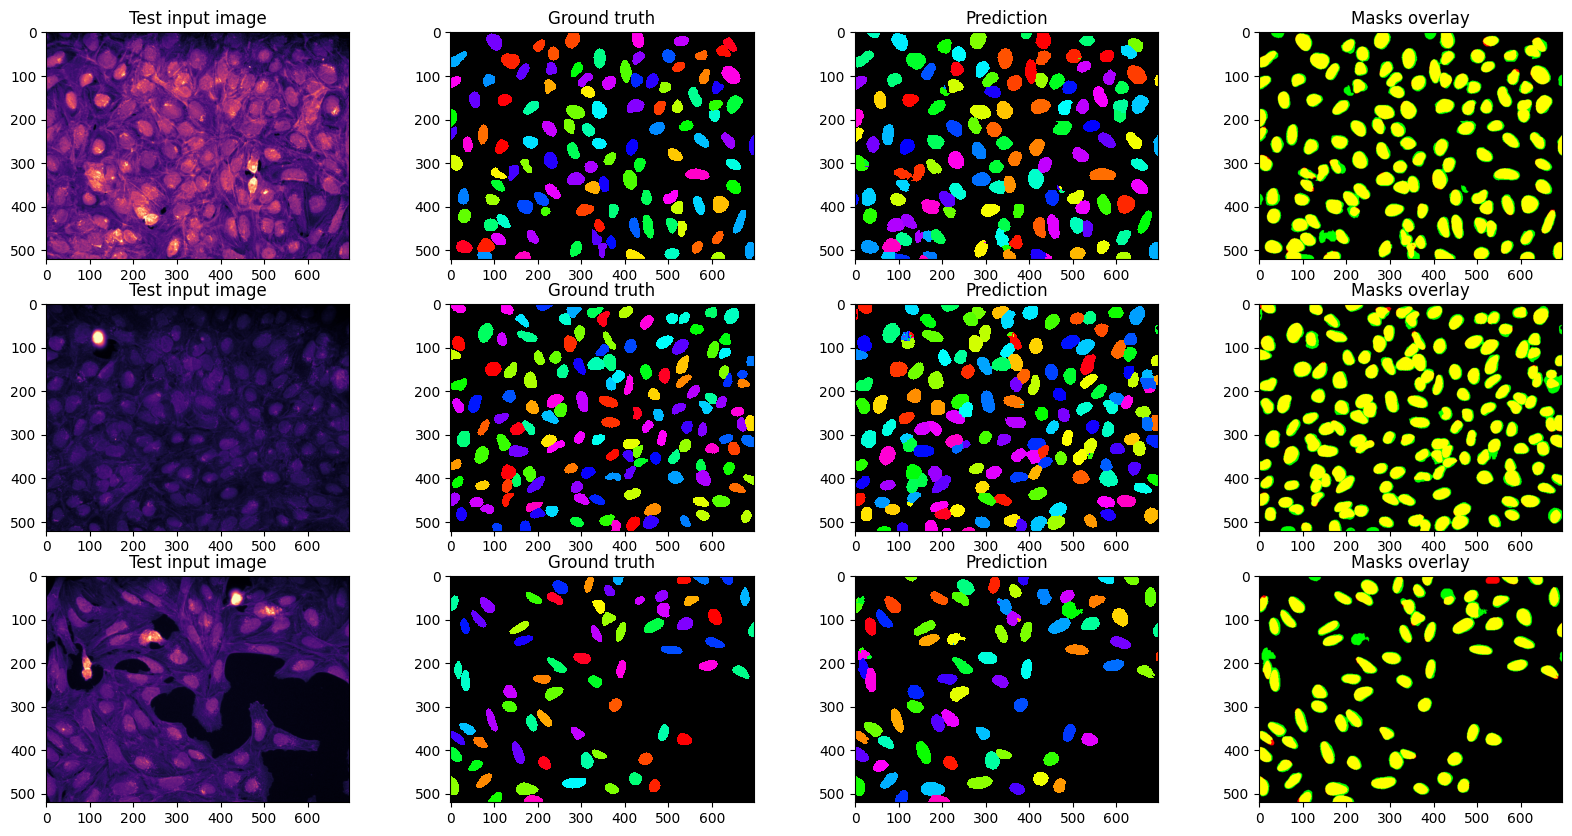

In [10]:
#@markdown ##Play to visualize some results from the test set
#@markdown The trained model was applied to the test images during the run; this cell shows, for a few of them:
#@markdown 1. The original **Test input image**.
#@markdown 2. Its corresponding **Ground truth** labels.
#@markdown 3. The model **Prediction** labels.
#@markdown 4. The **Masks overlay** (true positive pixels in yellow, false negative pixels in red, false positive pixels in green).

%matplotlib inline
import os
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
from IPython.display import display, Markdown as md

# Same run_id as the training cell; default to 2 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 2

# Whether the run predicted full images or per-patch; fall back to the config file on disk.
try:
    full_img = bool(biapy_config['TEST']['FULL_IMG'])
except NameError:
    import yaml
    with open('2d_instance_segmentation_config.yaml') as f:
        full_img = bool(yaml.safe_load(f).get('TEST', {}).get('FULL_IMG', False))

final_results = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id))
instance_results = os.path.join(
    final_results, 'full_image_instances' if full_img else 'per_image_instances'
)

if not os.path.isdir(instance_results):
    raise FileNotFoundError(
        "Test predictions not found: {}\n"
        "Re-run the config cell and the training cell with TEST.ENABLE = True "
        "(and a matching run_id) so BiaPy writes the test-set instance masks.".format(instance_results)
    )

display(md("Resulting images are in `{}`".format(instance_results)))

ids_pred = sorted(f for f in os.listdir(instance_results) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_input = sorted(f for f in os.listdir(test_data_path) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_gt = sorted(f for f in os.listdir(test_data_gt_path) if f.lower().endswith(('.tif', '.tiff', '.png')))

# random color map for the instance labels (background forced to black)
seed = 1
rng = np.random.default_rng(seed)
vals = np.linspace(0, 1, 256)
rng.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.]

n_available = min(len(ids_input), len(ids_pred), len(ids_gt))
samples_to_show = min(n_available, 3)
chosen_images = rng.choice(n_available, samples_to_show, replace=False)

test_samples, test_sample_preds, test_sample_gt = [], [], []
for k in chosen_images:
    test_samples.append(imread(os.path.join(test_data_path, ids_input[k])))
    test_sample_preds.append(imread(os.path.join(instance_results, ids_pred[k])).astype(np.uint16))
    test_sample_gt.append(imread(os.path.join(test_data_gt_path, ids_gt[k])).astype(np.uint16))

plt.figure(figsize=(20, 10))
index = 1
for j in range(samples_to_show):
    plt.subplot(samples_to_show, 4, index)
    plt.title("Test input image")
    plt.imshow(test_samples[j], cmap='magma',
               vmin=np.percentile(test_samples[j], 0.1), vmax=np.percentile(test_samples[j], 99.9))

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Ground truth")
    plt.imshow(test_sample_gt[j], cmap=cmap, interpolation='nearest')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Prediction")
    plt.imshow(test_sample_preds[j], cmap=cmap, interpolation='nearest')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Masks overlay")
    b = np.zeros(test_sample_gt[j].shape)
    overlay = np.dstack((test_sample_gt[j] > 0, test_sample_preds[j] > 0, b))
    plt.imshow(overlay)

    index += 1
plt.show()

## Did the training converge?

The loss should go down and the IoU up. If the training loss keeps falling while the
validation loss starts rising, the network is memorising the training images instead
of learning something general: that is overfitting, and it is the moment to stop.

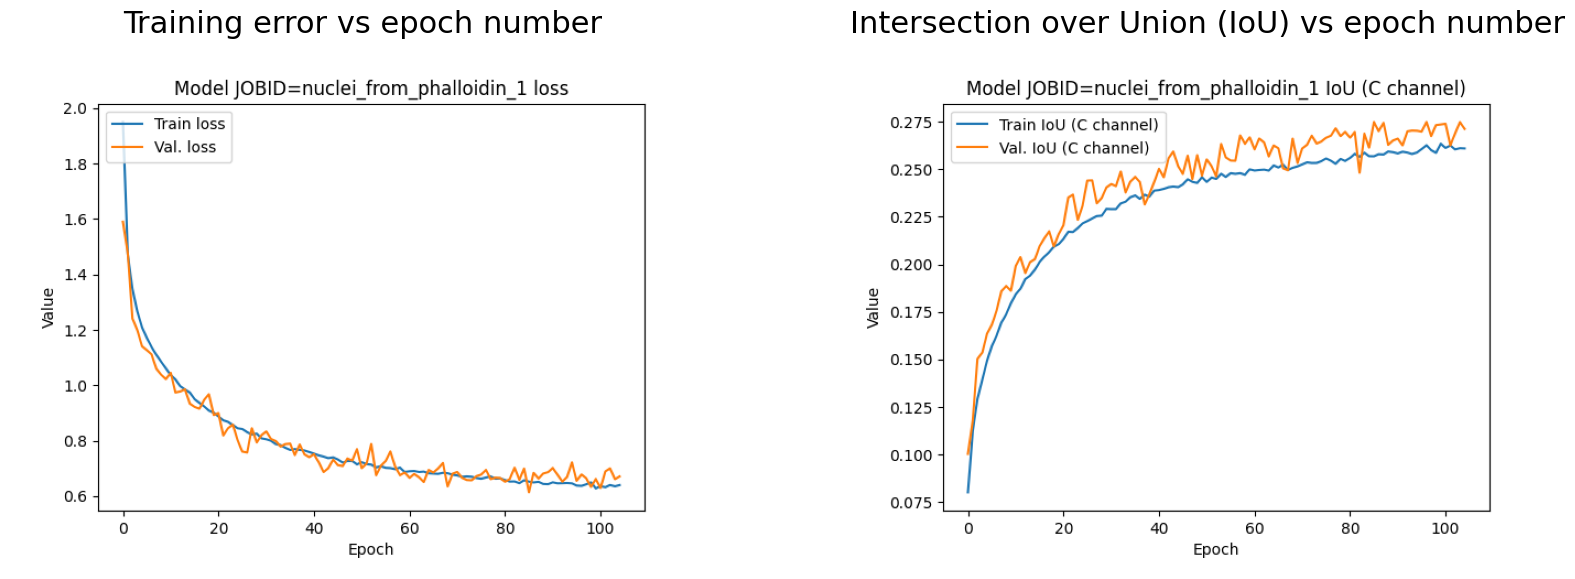

In [11]:
#@markdown ##Play the cell to show a plot of training error vs. epoch number and IoU vs epoch number
#@markdown #### Each channel that composes the instance representation has its own chart. Here, only the first plot found in the 'chart' result folder is shown, but there may be more depending on the selected representation.
import os
import matplotlib.pyplot as plt
from skimage.io import imread

# Use the same run_id as the training cell; default to 2 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 2

plot_dir = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id), 'charts')
if not os.path.isdir(plot_dir):
    raise FileNotFoundError(
        "Charts folder not found: {}\n"
        "Run the training cell above first (and make sure its run_id matches).".format(plot_dir)
    )

plots = sorted(f for f in os.listdir(plot_dir) if f.lower().endswith('.png'))

loss_file = [x for x in plots if "loss" in x][0]
loss_plot = imread(os.path.join(plot_dir, loss_file))

first_channel_file = [x for x in plots if "loss" not in x][0]
iou_plot = imread(os.path.join(plot_dir, first_channel_file))

fig = plt.figure( figsize = (20,10))
ax1 = plt.subplot( 1, 2, 1 )
_ = plt.imshow( loss_plot )
_ = plt.axis('off')
ax1.set_title( 'Training error vs epoch number', fontdict = {'fontsize':22})

ax2 = plt.subplot( 1, 2, 2 )
_ = plt.imshow( iou_plot )
_ = plt.axis('off')
_= ax2.set_title( 'Intersection over Union (IoU) vs epoch number', fontdict = {'fontsize':22})

# Play with the settings

The run above used the settings in the template YAML. Almost none of them are
obviously right — they are choices, and changing them changes the result.

Rather than editing the config cell each time and losing the previous run, the
function below trains one model under a name of its own. Every run keeps its own
config file, its own output folder and its own charts, so runs can be compared
afterwards.

Each run takes as long as the first one did, so pick the settings you want to try
rather than running everything. To look at the result of a run, set `job_name` to its
name and run the two result cells above again.

## What to try

### 1. Augmentation

Augmentation shows the network rotated and flipped copies of the training images, so
that it does not learn that nuclei only appear in one orientation. With few training
images it usually matters a lot.

- `AUGMENTOR.ENABLE` — off, as in the example above
- `AUGMENTOR.ELASTIC` — deform the image, so shapes vary as well as orientations
- `AUGMENTOR.BRIGHTNESS` with `AUGMENTOR.BRIGHTNESS_FACTOR` — vary the intensity,
  which is what differs between wells and between imaging sessions

Does augmentation help here, and which kind? Think about what actually varies between
your images before switching one on.

### How long to train

- `TRAIN.EPOCHS` — one epoch is one pass over the training images
- `TRAIN.PATIENCE` — stop early when the validation loss has not improved for this
  many epochs

Look at the curves from the first run before choosing. If the validation loss was still
falling at the end, the model was stopped too early. If it had turned upwards while the
training loss kept falling, it trained too long and started memorising.

### Patch size and batch size

- `DATA.PATCH_SIZE` — the crops the network sees, for example `'(128, 128, 1)'`
- `TRAIN.BATCH_SIZE` — how many crops go through the network at once

Smaller patches give more crops per image and fit in less memory, but each crop shows
the network less context around a nucleus. These two settings together decide whether
the run fits on the GPU, so if you run out of memory, this is where to look.

### How the network describes an instance

A network outputs images, not objects. `PROBLEM.INSTANCE_SEG.DATA_CHANNELS` decides
what those output images mean, and the objects are reconstructed from them afterwards.
The template uses `BC`:

- `B` — background
- `C` — the contour of each object
- `D` — a distance map: for every pixel the distance to the nearest background

`BC` separates touching nuclei by predicting their contours. `BCD` adds the distance
map, which gives the reconstruction a second source of evidence about where one object
ends and the next begins.

- `{'PROBLEM.INSTANCE_SEG.DATA_CHANNELS': 'BCD'}`

Where would you expect the difference to show up — in the number of nuclei found, or
in the outlines of the ones that were found?

### Learning rate

- `TRAIN.LR` — how large a step the network takes at each update, `1e-4` in the
  template

Ten times larger and the loss curve becomes unstable; ten times smaller and it improves
very slowly. The shape of the loss curve tells you which of the two is happening.

### Fine-tuning instead of starting from scratch

All of the above trains from scratch. You can also start from the weights of a model
that was already trained, which is what fine-tuning means: the network begins with
something useful rather than with random numbers, and needs far less data.

- `MODEL.LOAD_CHECKPOINT: True`
- `PATHS.CHECKPOINT_FILE` — the checkpoint to start from
- `MODEL.ITEMS_TO_LOAD_FROM_CHECKPOINT` — `['weights', 'model_arch']` for fine-tuning
- `MODEL.SKIP_UNMATCHED_LAYERS: True` when the output does not have the same shape

Your first run produced a checkpoint, so you can fine-tune from it: train the first
model on half of the training images, then fine-tune it on the other half and compare
with training on all of them at once.

### The architecture

`MODEL.ARCHITECTURE` selects the network itself. BiaPy offers among others `unet`,
`resunet`, `attention_unet`, `seunet` and `multiresunet`.

- `{'MODEL.ARCHITECTURE': 'resunet'}`

This is the setting people reach for first and it is rarely where the gain is. Try it,
but compare the difference it makes with the difference augmentation or more training
data makes.


## Exercise: how much data do you actually need?

Train the same settings on a quarter, a half and all of the training images, and plot
the test score against the number of training images.

- Is the curve still rising at the end, or has it flattened?
- If it is still rising, annotating more images is worth more than any setting on this
  page. If it has flattened, it is not.

This is the question worth answering before spending a day on hyperparameters.

## Next: is the model any good?

The training charts only tell you whether training went well. Whether the model is
useful is a different question.

In `evaluation.ipynb` (day 2 deep learning kernel) we score this model on the test set
next to the generic StarDist and Cellpose models, and discuss which metric fits which
biological question. Let the training above finish first: BiaPy writes the test
predictions at the end of the run.